# Stage 3: Data Preprocessing & Cleaning

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('./data/raw/water_potability.csv')
print(f'Loaded: {df.shape} | Missing values: {df.isnull().sum().sum()}')

Loaded: (3276, 10) | Missing values: 1434


## 3.1 Duplicate Check & Data Type Validation

In [2]:
# Remove duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Removed duplicates. New shape: {df.shape}')
else:
    print('No duplicates — dataset is clean ✓')

# Validate data types
feature_cols = [c for c in df.columns if c != 'Potability']
for col in feature_cols:
    df[col] = df[col].astype(float)
df['Potability'] = df['Potability'].astype(int)

print(f'\nDataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')


Duplicate rows found: 0
No duplicates — dataset is clean ✓

Dataset shape: (3276, 10)
Missing values: 1434


## 3.2 Train-Test Split

⚠️ **IMPORTANT**: We split BEFORE preprocessing to prevent data leakage. Preprocessing parameters (imputation values, outlier bounds) will be fitted on training data only, then applied to test.


In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# 80-20 split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nClass distribution in training: {y_train.value_counts().to_dict()}')
print(f'Class distribution in test: {y_test.value_counts().to_dict()}')

Training set: (2620, 9)
Test set: (656, 9)

Class distribution in training: {0: 1598, 1: 1022}
Class distribution in test: {0: 400, 1: 256}


In [4]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# 80-20 split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nClass distribution in training: {y_train.value_counts().to_dict()}')
print(f'Class distribution in test: {y_test.value_counts().to_dict()}')


Training set: (2620, 9)
Test set: (656, 9)

Class distribution in training: {0: 1598, 1: 1022}
Class distribution in test: {0: 400, 1: 256}


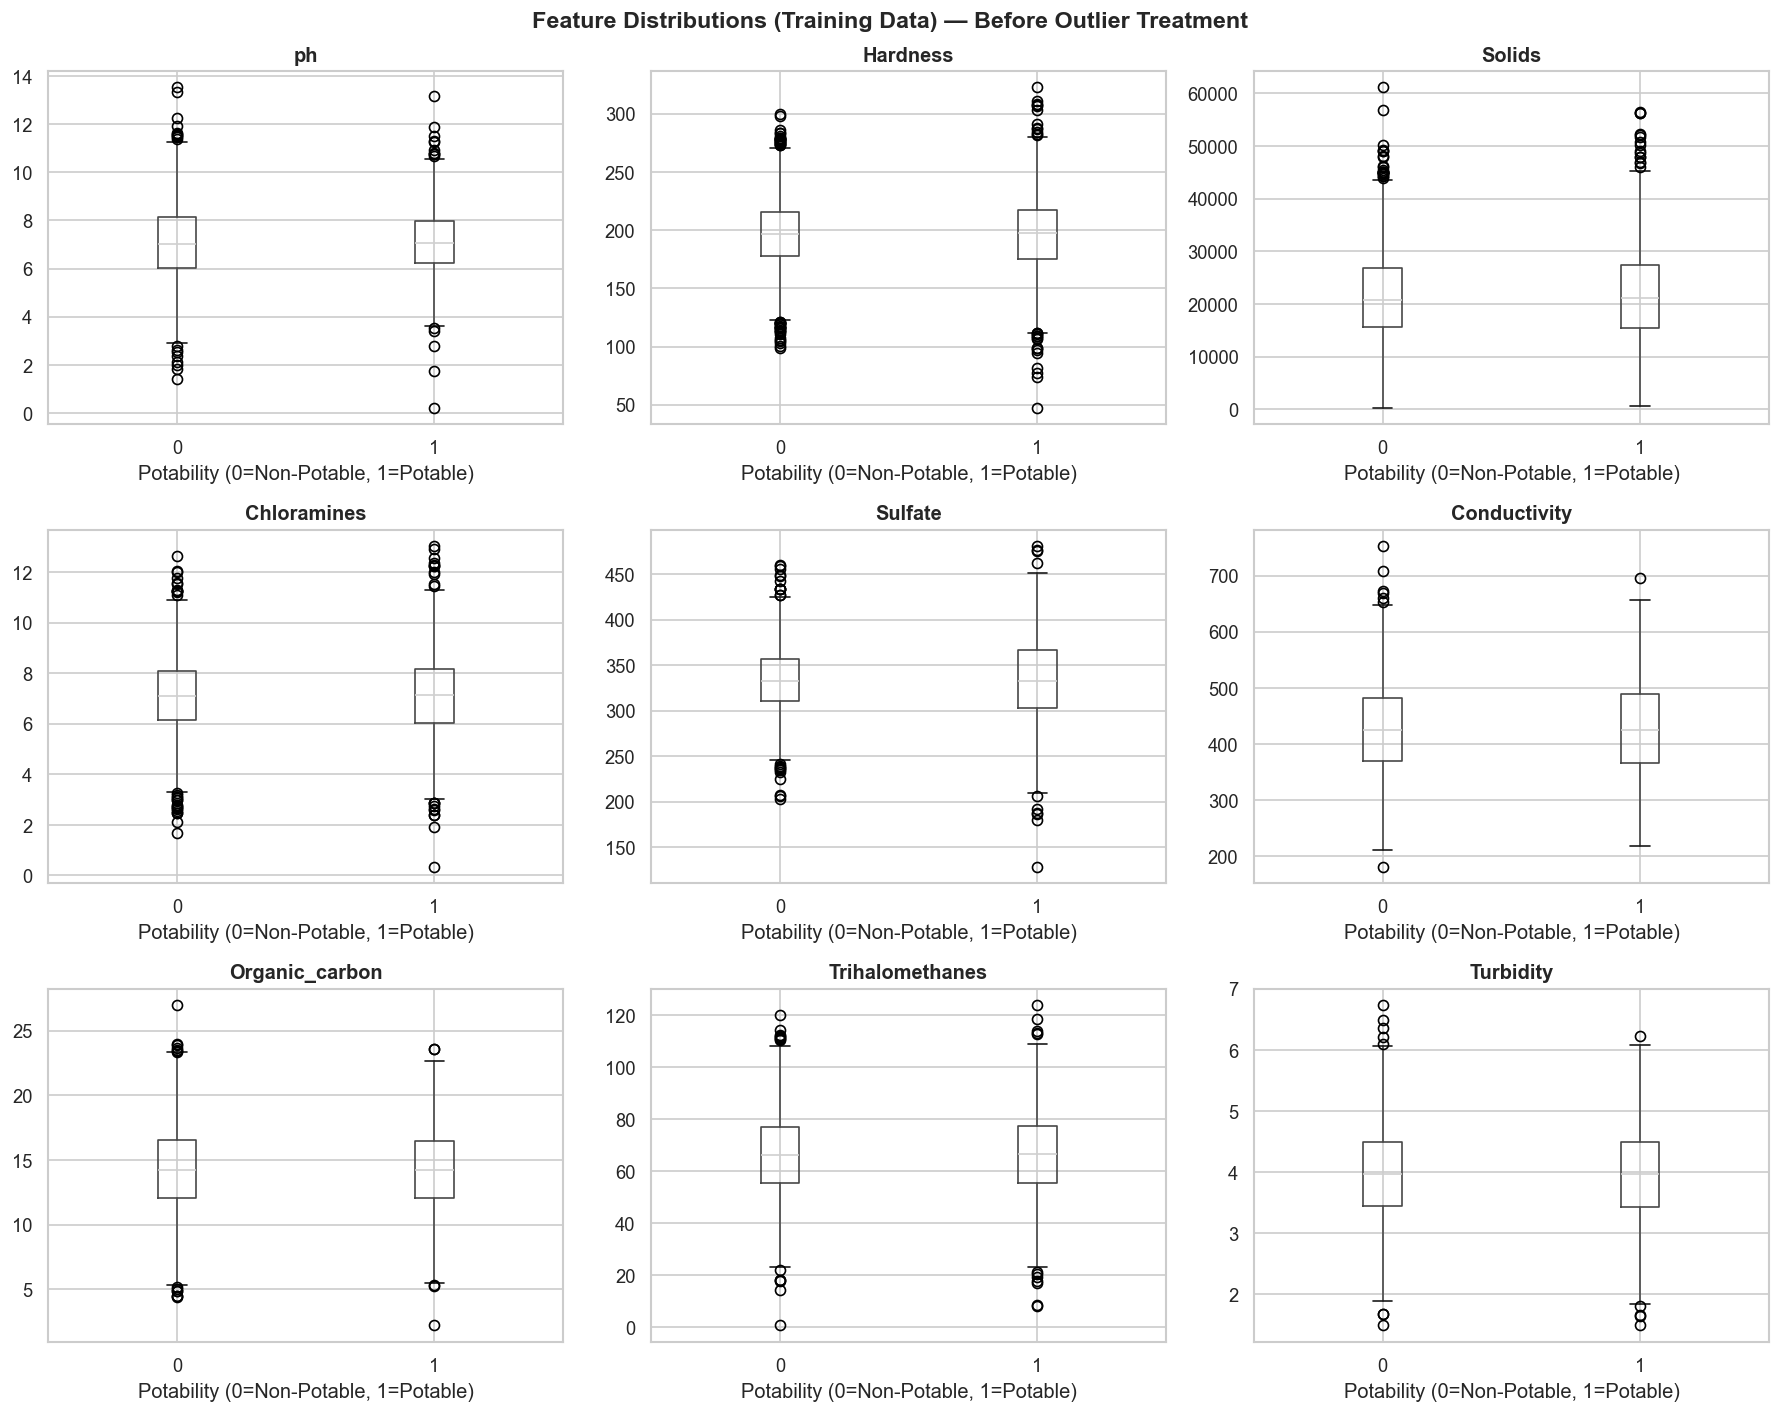

In [5]:
# Boxplots before outlier treatment (train data)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    train_with_target = X_train.copy()
    train_with_target['Potability'] = y_train
    train_with_target.boxplot(column=col, by='Potability', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Potability (0=Non-Potable, 1=Potable)')

plt.suptitle('Feature Distributions (Training Data) — Before Outlier Treatment', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/boxplots_before.png', bbox_inches='tight', dpi=150)
plt.show()

In [6]:
# Save preprocessed datasets
X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False, header=['Potability'])
y_test.to_csv('./data/processed/y_test.csv', index=False, header=['Potability'])

print('✓ Preprocessed datasets saved:')
print(f'  X_train: {X_train.shape} | Missing: {X_train.isnull().sum().sum()}')
print(f'  X_test: {X_test.shape} | Missing: {X_test.isnull().sum().sum()}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test: {y_test.shape}')

✓ Preprocessed datasets saved:
  X_train: (2620, 9) | Missing: 1146
  X_test: (656, 9) | Missing: 288
  y_train: (2620,)
  y_test: (656,)


## 3.5 Save Preprocessed Datasets

Save both train and test sets for use in feature engineering and model building.

In [7]:
# Calculate IQR bounds on TRAINING data only
outlier_bounds = {}
outlier_report = []

for col in feature_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_bounds[col] = {'lower': lower, 'upper': upper}
    
    n_outliers_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    n_outliers_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()
    
    outlier_report.append({
        'Feature': col, 
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3), 
        'Outliers in Train': n_outliers_train,
        'Outliers in Test': n_outliers_test
    })
    
    # Apply bounds to both train and test
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_report)
print('OUTLIER TREATMENT REPORT (bounds fitted on training data)')
print(outlier_df.to_string(index=False))

OUTLIER TREATMENT REPORT (bounds fitted on training data)
        Feature  Lower Bound  Upper Bound  Outliers in Train  Outliers in Test
             ph        3.147       11.016                 35                11
       Hardness      118.428      275.230                 73                15
         Solids    -1956.418    44617.796                 36                12
    Chloramines        3.138       11.097                 53                 7
        Sulfate      229.798      438.260                 34                 8
   Conductivity      192.433      659.115                  7                 2
 Organic_carbon        5.322       23.274                 20                 5
Trihalomethanes       23.032      109.644                 26                 5
      Turbidity        1.856        6.078                 14                 6


## 3.4 Outlier Detection & Treatment: Fit on Training Data Only

IQR bounds are calculated on training data only, then applied to both train and test sets.

In [8]:
# Fit imputation values on TRAINING data only
features_with_missing = ['ph', 'Sulfate', 'Trihalomethanes']
imputation_values = {}

print('Imputation values fitted on TRAINING data:')
for feature in features_with_missing:
    # Fit on training data
    train_with_target = X_train.copy()
    train_with_target['Potability'] = y_train
    
    class_medians = train_with_target.groupby('Potability')[feature].median()
    imputation_values[feature] = class_medians
    
    print(f'\n{feature}:')
    print(f'  Non-Potable (0): {class_medians[0]:.4f}')
    print(f'  Potable (1):     {class_medians[1]:.4f}')

# Apply fitted imputation to TRAINING data
for feature in features_with_missing:
    for cls in [0, 1]:
        mask = (X_train.index.isin(y_train[y_train == cls].index)) & (X_train[feature].isnull())
        X_train.loc[mask, feature] = imputation_values[feature][cls]
        
        mask_test = (X_test.index.isin(y_test[y_test == cls].index)) & (X_test[feature].isnull())
        X_test.loc[mask_test, feature] = imputation_values[feature][cls]

print(f'\n✓ Training set missing values: {X_train.isnull().sum().sum()}')
print(f'✓ Test set missing values: {X_test.isnull().sum().sum()}')

Imputation values fitted on TRAINING data:

ph:
  Non-Potable (0): 7.0135
  Potable (1):     7.0636

Sulfate:
  Non-Potable (0): 333.1483
  Potable (1):     332.9364

Trihalomethanes:
  Non-Potable (0): 66.2848
  Potable (1):     66.6861

✓ Training set missing values: 0
✓ Test set missing values: 0


## 3.3 Imputation: Fit on Training Data Only

We fit class-wise median imputation on the training set, then apply those same values to test set.

In [9]:
# Calculate IQR bounds on TRAINING data only
outlier_bounds = {}
outlier_report = []

for col in feature_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_bounds[col] = {'lower': lower, 'upper': upper}
    
    n_outliers_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    n_outliers_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()
    
    outlier_report.append({
        'Feature': col, 
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3), 
        'Outliers in Train': n_outliers_train,
        'Outliers in Test': n_outliers_test
    })
    
    # Apply bounds to both train and test
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_report)
print('OUTLIER TREATMENT REPORT (bounds fitted on training data)')
print(outlier_df.to_string(index=False))


OUTLIER TREATMENT REPORT (bounds fitted on training data)
        Feature  Lower Bound  Upper Bound  Outliers in Train  Outliers in Test
             ph        3.888       10.260                115                27
       Hardness      118.428      275.230                  0                 0
         Solids    -1956.418    44617.796                  0                 0
    Chloramines        3.138       11.097                  0                 0
        Sulfate      268.146      399.153                225                54
   Conductivity      192.433      659.115                  0                 0
 Organic_carbon        5.322       23.274                  0                 0
Trihalomethanes       26.338      106.350                 47                 7
      Turbidity        1.856        6.078                  0                 0


## 3.5 Save Preprocessed Datasets

Save both train and test sets for use in feature engineering and model building.


In [10]:
# Save preprocessed datasets
X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False, header=['Potability'])
y_test.to_csv('./data/processed/y_test.csv', index=False, header=['Potability'])

print('✓ Preprocessed datasets saved:')
print(f'  X_train: {X_train.shape} | Missing: {X_train.isnull().sum().sum()}')
print(f'  X_test: {X_test.shape} | Missing: {X_test.isnull().sum().sum()}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test: {y_test.shape}')


✓ Preprocessed datasets saved:
  X_train: (2620, 9) | Missing: 0
  X_test: (656, 9) | Missing: 0
  y_train: (2620,)
  y_test: (656,)
